# Supplementary Figure 2 — Q-learning model with choice kernel captures trial-by-trial dynamics of the 2-armed bandit performance and captures differences across individuals

Source: manuscript BioRxiv PDF (`~/Downloads/2026.06.30.734629v1.full (4).pdf`), Supplementary
Figure 2 legend (Supplementary Figures section, page 31) and the Methods "Reinforcement Learning
models" / "Model Selection" subsections (pages 38-39).

**Source notebook:** `_source_archive/by_figure/SuppFig2/01_Reversal_80_20_model.ipynb` (the
primary candidate per `_source_archive/INDEX.md`'s Supp Fig 2 row). The secondary candidate,
`04_ReversalTask_80-20_v4_candidate.ipynb`, was checked and has no `fit_qlearning_*` model family
and no matching 4-model comparison anywhere in it -- 01 is the one that actually produces this
figure's content (its `SYSTEMATIC MODEL COMPARISON` cell fits exactly `MODEL_NAMES = ['pure',
'original', 'forgetting', 'adaptive_forgetting']` and computes `test_nll`/`r_phigh`/`r_pswitch`/
`r_switch_trial`/`composite` -- the same five quantities as this figure's panel e).

Model forms are ported from that notebook's own `fit_qlearning_pure` (line 2363),
`fit_qlearning_forgetting` (line 2270), and `fit_qlearning_adaptive_forgetting` (line 2310) --
see `src/behavior_metrics/rl_model_comparison.py` and `config.yaml`'s `suppfig2` section for full
line-number provenance and every discrepancy found (Q-value initialization, single-x0-vs-50-
restart, 70/30-vs-80/20 split -- all called out explicitly rather than silently reconciled). The
"+sticky" model (panel b) is **not** reimplemented -- per this figure's task instructions it
reuses `src/behavior_metrics/q_following_model.py`'s `fit_sticky_qlearning`/`compute_qvalues_sticky`
directly (the identical model, already fit/verified for Fig 4 / Supp Fig 3 on the same
Reversal/80-20 2-ABT data).

Panels: (a) pure Q-learning (α, β); (b) +sticky choice kernel (α, β, κ) -- reuses Supp Fig 3's
fitting code; (c) +forgetting (α, β, κ, τ); (d) +adaptive forgetting (α, β, κ, τ_max, decay);
(e) model comparison across four metrics (test NLL, r(p_high), r(p_switch), trial-by-trial
r(switch)) plus a composite score.

**Standing constraint honored throughout:** no parameter is tuned to force agreement with the
manuscript's printed example values (α=0.70/β=1.74 for pure QL, etc.) -- every fit below is
recomputed independently on this pipeline's own train/test split and reported plainly, including
where it disagrees with the manuscript (e.g. which model the composite score actually favors).
Where a session-vs-animal pseudoreplication risk exists (panel e's per-session vs. per-animal
metrics), both are reported and the per-animal version is treated as the real one, per this
pipeline's standing convention.

In [1]:
import os
import sys
import json
import time
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config, load_snapshot
from src.behavior_metrics import rl_model_comparison as rlmc
from src.plotting.style import apply_style
from src.plotting import supp_fig2 as plotting

from IPython.display import SVG, display

config = load_config()
apply_style(config)
cfg = config["suppfig2"]
cfg_suppfig3 = config["suppfig3"]  # reused directly for the sticky-model fit (panel b)

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "SuppFig2")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {
    "_stage": "Supp Fig 2: 4-model Q-learning comparison (pure QL / +sticky / +forgetting / +adaptive forgetting)",
    "_manuscript_quoted_example_values_for_comparison_only": {
        "note": "Quoted here for side-by-side comparison ONLY -- not used as a fitting target "
                "anywhere below (see standing constraint in the header cell).",
        "pure_ql": {"alpha": 0.70, "beta": 1.74},
        "sticky": {"alpha": 0.59, "beta": 1.63, "kappa": 1.29},
        "forgetting": {"alpha": 0.43, "beta": 3.18, "kappa": 1.39, "tau": 0.95},
        "adaptive_forgetting": {"alpha": 0.44, "beta": 2.87, "kappa": 1.39, "tau_max": 0.99, "decay": 20.0},
    },
}

## Load data and prepare features

In [2]:
df_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df = rlmc.prepare_dataframe(df_raw, cfg["task_type"], cfg["prob_condition"])
print(f"Loaded {len(df):,} trials, {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals after filtering for "
      f"{cfg['task_type']}/{cfg['prob_condition']} (same snapshot/filter as Fig 3 / Supp Fig 3).")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/q_following_model.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


Loaded 36,673 trials, 100 sessions, 5 animals after filtering for Reversal/80-20 (same snapshot/filter as Fig 3 / Supp Fig 3).


In [3]:
train_sessions, test_sessions = rlmc.split_train_test_sessions(
    df, cfg["train_test_split"]["test_size"], cfg["train_test_split"]["seed"]
)
print(f"Train sessions: {len(train_sessions)}, Test (held-out) sessions: {len(test_sessions)} "
      f"(per-animal {cfg['train_test_split']['test_size']:.0%} split, seed={cfg['train_test_split']['seed']})")
manifest["n_train_sessions"] = len(train_sessions)
manifest["n_test_sessions"] = len(test_sessions)

Train sessions: 79, Test (held-out) sessions: 21 (per-animal 20% split, seed=42)


## Fit all four models per animal (train sessions) and generate trial-by-trial predictions

Each model is fit once per animal on that animal's train sessions (single-x0 L-BFGS-B, matching
this pipeline's existing convention for Fig 4 / Supp Fig 3 -- see `config.yaml`'s `suppfig2` note
on the manuscript's 50-restart claim), then run forward (teacher-forced on the animal's actual
choice/reward sequence, resetting Q-values at each session boundary) across ALL sessions
(train+test) to generate `Model_P_Right` for every trial. `Model_P_High`/`Model_P_Switch` are then
derived analytically per trial from `Model_P_Right`, the block's high-probability side, and the
animal's actual previous choice -- the same analytic form the source notebook itself uses for its
own trial-by-trial `r_switch_trial` correlation.

In [4]:
t0 = time.time()
df_out, params_by_model = rlmc.fit_and_predict_all_models(
    df, cfg, cfg_suppfig3, train_sessions, test_sessions
)
windows = rlmc.build_reversal_windows(df_out, cfg["block_position_pre"], cfg["block_position_post"])
print(f"Fit all 4 models x {df['Animal_Name'].nunique()} animals and built reversal-aligned "
      f"windows in {time.time() - t0:.1f}s")

manifest["fitted_parameters"] = {
    model: params_by_model[model].round(4).to_dict(orient="index") for model in rlmc.MODEL_NAMES
}
for model in rlmc.MODEL_NAMES:
    mean_params = params_by_model[model].mean()
    print(f"\n{rlmc.MODEL_LABELS[model]}: " + ", ".join(f"{k}={v:.3f}" for k, v in mean_params.items()))

Fit all 4 models x 5 animals and built reversal-aligned windows in 30.8s

Pure QL: alpha=0.732, beta=1.747, train_nll=0.567

w/Sticky: alpha=0.746, beta=1.123, kappa=1.268, train_nll=2602.876

w/Forgetting: alpha=0.464, beta=3.065, kappa=1.392, tau=0.946, train_nll=0.417

w/Adaptive: alpha=0.469, beta=2.792, kappa=1.384, tau_max=0.990, decay=20.000, train_nll=0.420


## Panel a: Pure QL

**a,** Pure Q-learning model (parameters: α, β). Mean p(high probability choice) (top)
and p(switch) (bottom) aligned to block reversal (trial position = 0, dashed vertical line) for
marmosets (grey) and model simulations (blue). Shaded regions indicate ±SEM. Right: Session-level
p(switch) predicted by the model versus observed marmoset p(switch). Each dot represents one
session. Dashed line indicates unity. Mean fitted parameters shown.

In [5]:
curves_pure = rlmc.block_position_curves(windows, "pure", test_only=True)
scatter_pure = rlmc.session_switch_scatter(df_out, "pure", test_only=True)
mean_params_pure = params_by_model["pure"].mean()
print(f"Pure QL mean fitted params (n={len(params_by_model['pure'])} animals): " +
      ", ".join(f"{k}={v:.3f}" for k, v in mean_params_pure.items()))
manifest["panel_a_pure"] = {
    "mean_fitted_params": {k: float(v) for k, v in mean_params_pure.items() if k != "train_nll"},
    "n_scatter_sessions": int(len(scatter_pure)),
}

pure_svg = os.path.join(FIG_DIR, "SuppFig2_a_pure.svg")
plotting.plot_model_panel(curves_pure, scatter_pure, mean_params_pure, "pure", config, pure_svg)

Pure QL mean fitted params (n=5 animals): alpha=0.732, beta=1.747, train_nll=0.567


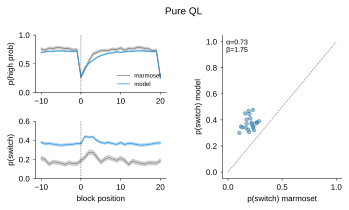

In [6]:
display(SVG(pure_svg))

## Panel b: w/Sticky

**b,** As shown in panel (**a**) but for the Q-learning model with sticky term
(parameters: α, β, κ).

In [7]:
curves_sticky = rlmc.block_position_curves(windows, "sticky", test_only=True)
scatter_sticky = rlmc.session_switch_scatter(df_out, "sticky", test_only=True)
mean_params_sticky = params_by_model["sticky"].mean()
print(f"w/Sticky mean fitted params (n={len(params_by_model['sticky'])} animals): " +
      ", ".join(f"{k}={v:.3f}" for k, v in mean_params_sticky.items()))
manifest["panel_b_sticky"] = {
    "mean_fitted_params": {k: float(v) for k, v in mean_params_sticky.items() if k != "train_nll"},
    "n_scatter_sessions": int(len(scatter_sticky)),
}

sticky_svg = os.path.join(FIG_DIR, "SuppFig2_b_sticky.svg")
plotting.plot_model_panel(curves_sticky, scatter_sticky, mean_params_sticky, "sticky", config, sticky_svg)

w/Sticky mean fitted params (n=5 animals): alpha=0.746, beta=1.123, kappa=1.268, train_nll=2602.876


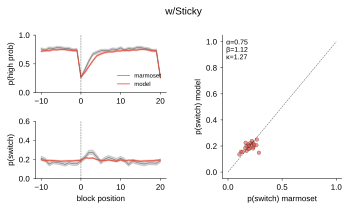

In [8]:
display(SVG(sticky_svg))

## Panel c: w/Forgetting

**c,** As shown in panel (**a**) but for the Q-learning model with forgetting term
(parameters: α, β, κ, τ).

In [9]:
curves_forgetting = rlmc.block_position_curves(windows, "forgetting", test_only=True)
scatter_forgetting = rlmc.session_switch_scatter(df_out, "forgetting", test_only=True)
mean_params_forgetting = params_by_model["forgetting"].mean()
print(f"w/Forgetting mean fitted params (n={len(params_by_model['forgetting'])} animals): " +
      ", ".join(f"{k}={v:.3f}" for k, v in mean_params_forgetting.items()))
manifest["panel_c_forgetting"] = {
    "mean_fitted_params": {k: float(v) for k, v in mean_params_forgetting.items() if k != "train_nll"},
    "n_scatter_sessions": int(len(scatter_forgetting)),
}

forgetting_svg = os.path.join(FIG_DIR, "SuppFig2_c_forgetting.svg")
plotting.plot_model_panel(curves_forgetting, scatter_forgetting, mean_params_forgetting, "forgetting", config, forgetting_svg)

w/Forgetting mean fitted params (n=5 animals): alpha=0.464, beta=3.065, kappa=1.392, tau=0.946, train_nll=0.417


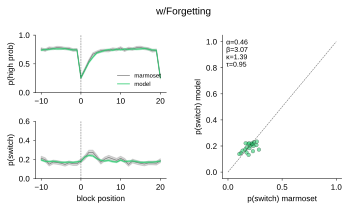

In [10]:
display(SVG(forgetting_svg))

## Panel d: w/Adaptive

**d,** As shown in panel (**a**) but for the Q-learning model with adaptive forgetting
(parameters: α, β, κ, τ_max, decay).

In [11]:
curves_adaptive_forgetting = rlmc.block_position_curves(windows, "adaptive_forgetting", test_only=True)
scatter_adaptive_forgetting = rlmc.session_switch_scatter(df_out, "adaptive_forgetting", test_only=True)
mean_params_adaptive_forgetting = params_by_model["adaptive_forgetting"].mean()
print(f"w/Adaptive mean fitted params (n={len(params_by_model['adaptive_forgetting'])} animals): " +
      ", ".join(f"{k}={v:.3f}" for k, v in mean_params_adaptive_forgetting.items()))
manifest["panel_d_adaptive_forgetting"] = {
    "mean_fitted_params": {k: float(v) for k, v in mean_params_adaptive_forgetting.items() if k != "train_nll"},
    "n_scatter_sessions": int(len(scatter_adaptive_forgetting)),
}

adaptive_forgetting_svg = os.path.join(FIG_DIR, "SuppFig2_d_adaptive_forgetting.svg")
plotting.plot_model_panel(curves_adaptive_forgetting, scatter_adaptive_forgetting, mean_params_adaptive_forgetting, "adaptive_forgetting", config, adaptive_forgetting_svg)

w/Adaptive mean fitted params (n=5 animals): alpha=0.469, beta=2.792, kappa=1.384, tau_max=0.990, decay=20.000, train_nll=0.420


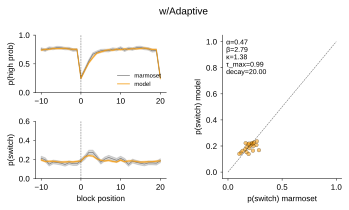

In [12]:
display(SVG(adaptive_forgetting_svg))

## Panel e: model comparison

**e,** Model comparison across four metrics: test negative log-likelihood (NLL), correlation
between predicted and observed p(high probability choice), correlation between predicted and
observed p(switch), trial-by-trial correlation of switching behavior, and composite score
averaging across all metrics. Bars indicate mean ±SEM across sessions.

**Pseudoreplication note:** the legend above says "mean ±SEM across sessions", but sessions from
the same animal are not independent draws (the same animal-level fitted model generates all of
that animal's predictions). Per this pipeline's standing convention (see Fig 2/3 WSLS, Supp Fig 3
outcome panel), both the naive session-level version (n=21 held-out test sessions, printed below
for transparency) and the per-animal version (n=5 animals, matching how the source notebook's own
`SYSTEMATIC MODEL COMPARISON` cell actually computes these statistics -- one row per animal, not
per session) are reported; the per-animal version is treated as the real one and is what panel e
itself plots.

In [13]:
comparison = rlmc.model_comparison_table(df_out, windows)
print("Per-animal metrics (n=5 animals per model) -- treated as the real unit:")
print(comparison.to_string(index=False))

naive_frames = [rlmc.naive_session_level_metrics(df_out, m) for m in rlmc.MODEL_NAMES]
naive = pd.concat(naive_frames, ignore_index=True)
print(f"\nNaive session-level test_nll / r_switch_trial (n={naive['session_id'].nunique()} held-out "
      "test sessions, PSEUDOREPLICATED -- shown for comparison only):")
print(naive.groupby("model")[["test_nll", "r_switch_trial"]].agg(["mean", "sem"]))

manifest["model_comparison_per_animal"] = {
    model: {
        col: {"mean": float(comparison.loc[comparison["model"] == model, col].mean()),
              "sem": float(comparison.loc[comparison["model"] == model, col].sem())}
        for col in ["test_nll", "r_phigh", "r_pswitch", "r_switch_trial", "composite"]
    }
    for model in rlmc.MODEL_NAMES
}
manifest["model_comparison_naive_session_level_PSEUDOREPLICATED"] = {
    model: {
        col: {"mean": float(naive.loc[naive["model"] == model, col].mean()),
              "sem": float(naive.loc[naive["model"] == model, col].sem())}
        for col in ["test_nll", "r_switch_trial"]
    }
    for model in rlmc.MODEL_NAMES
}
winner = comparison.groupby("model")["composite"].mean().idxmax()
print(f"\nModel with highest mean composite score (per-animal, n=5): {rlmc.MODEL_LABELS[winner]}")
manifest["winner_by_composite_per_animal"] = winner

e_svg = os.path.join(FIG_DIR, "SuppFig2_e_model_comparison.svg")
plotting.plot_model_comparison(comparison, config, e_svg)

Per-animal metrics (n=5 animals per model) -- treated as the real unit:
   animal               model  test_nll  r_phigh  r_pswitch  r_switch_trial  nll_score  composite
    Fiona                pure  0.484692 0.970621   0.788803        0.280491   0.294704   0.583655
 Knuckles                pure  0.576257 0.963597   0.531786        0.278669   0.161464   0.483879
    Sonic                pure  0.653291 0.900272   0.541458        0.145532   0.049368   0.409158
Sunflower                pure  0.501985 0.970283   0.598453        0.385027   0.269540   0.555825
     Zazu                pure  0.687218 0.447226   0.298023        0.115163   0.000000   0.215103
    Fiona              sticky  0.334346 0.975997   0.714075        0.280127   0.513479   0.620919
 Knuckles              sticky  0.490142 0.957566   0.518814        0.272739   0.286773   0.508973
    Sonic              sticky  0.456496 0.925983   0.471931        0.144495   0.335733   0.469535
Sunflower              sticky  0.456846 0.9520

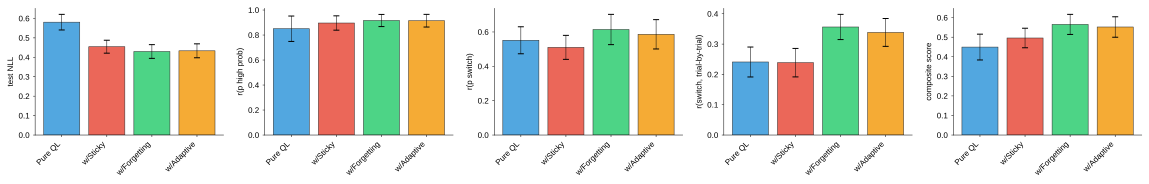

In [14]:
display(SVG(e_svg))

## Values manifest

In [15]:
manifest_path = os.path.join(MANIFEST_DIR, "SuppFig2.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Saved values manifest: {manifest_path}")
print(json.dumps(manifest, indent=2, default=str)[:4000] + "\n... (truncated for display)")

Saved values manifest: ../outputs/values_manifests/SuppFig2.json
{
  "_stage": "Supp Fig 2: 4-model Q-learning comparison (pure QL / +sticky / +forgetting / +adaptive forgetting)",
  "_manuscript_quoted_example_values_for_comparison_only": {
    "note": "Quoted here for side-by-side comparison ONLY -- not used as a fitting target anywhere below (see standing constraint in the header cell).",
    "pure_ql": {
      "alpha": 0.7,
      "beta": 1.74
    },
    "sticky": {
      "alpha": 0.59,
      "beta": 1.63,
      "kappa": 1.29
    },
    "forgetting": {
      "alpha": 0.43,
      "beta": 3.18,
      "kappa": 1.39,
      "tau": 0.95
    },
    "adaptive_forgetting": {
      "alpha": 0.44,
      "beta": 2.87,
      "kappa": 1.39,
      "tau_max": 0.99,
      "decay": 20.0
    }
  },
  "n_trials": 36673,
  "n_sessions": 100,
  "n_animals": 5,
  "n_train_sessions": 79,
  "n_test_sessions": 21,
  "fitted_parameters": {
    "pure": {
      "Fiona": {
        "alpha": 0.6036,
        "beta"